In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader, ConcatDataset, random_split
import torchvision.transforms as transforms
import torchvision.models as models
from torch import optim
import json
import torch.optim.lr_scheduler as lr_scheduler
import os

from tqdm import tqdm
from utils import util_functions, metric_functions, custom_dataset

In [2]:
train_labels_path = os.path.join('dataset', 'train.csv')
test_labels_path = os.path.join('dataset', 'test.csv')

train_images_dir = os.path.join('dataset', 'train')
test_images_dir = os.path.join('dataset', 'test')

train_labels_df = pd.read_csv(train_labels_path)
test_labels_df = pd.read_csv(test_labels_path)

In [8]:
mean = [0.0, 0.0, 0.0]
std = [1.0, 1.0, 1.0]

train_transformer = transforms.Compose([transforms.Resize((224, 224)),
                                transforms.RandomHorizontalFlip(),
                                transforms.RandomRotation(15),
                                transforms.ToTensor(),
                                transforms.Normalize(mean, std)])
test_transformer = transforms.Compose([transforms.Resize((224, 224)),
                                transforms.ToTensor(),
                                transforms.Normalize(mean, std)])

base_transformer =  transforms.Compose([transforms.Resize((224, 224)),
                                transforms.ToTensor()])

In [ ]:
dataset = custom_dataset.CustomDataset(images_dir=train_images_dir, 
                                                df=train_labels_df, transforms=base_transformer)
base_transformer()

In [9]:
## Checking how many different classes we have
no_classes = len(list(train_labels_df['label'].unique()))

dataset = custom_dataset.CustomDataset(images_dir=train_images_dir, 
                                                df=train_labels_df, transforms=test_transformer)
augmented_dataset = custom_dataset.CustomDataset(images_dir=train_images_dir, 
                                                df=train_labels_df, transforms=train_transformer)
# Define the sizes for the training and validation sets
train_size = int(0.8 * len(dataset))  # 80% of the data for training
val_size = len(dataset) - train_size   # Remaining 20% for validation

# Use random_split to create training and validation sets
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_dataset = ConcatDataset([train_dataset, augmented_dataset])
print(len(train_dataset), len(val_dataset))
BATCH_SIZE = 256 # efficientnetv2-m got cuda out of memory with 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

7443 827


In [10]:
def train_loop(n_epochs, model, optimizer, train_loader, valid_loader, device,
                                criterion, scheduler=None):

    model = model.to(device)
        
    best_valid_loss = np.Inf

    train_loss_list = []
    valid_loss_list = []
    train_acc_list = []
    valid_acc_list = []
    result_directory = 'results'
    results_folder = util_functions.create_result_folder_by_date_and_time_folder(result_directory)
    for epoch in tqdm(range(n_epochs)):
        train_loss, train_acc = metric_functions.train_fn(data_loader=train_loader, model=model, criterion=criterion, 
                                optimizer=optimizer, device=device)
        valid_loss, valid_acc = metric_functions.eval_fn(data_loader=valid_loader, model=model, criterion=criterion,
                                        device=device)
        if scheduler is not None:
            scheduler.step()
        
        # Access the current learning rate
        if scheduler is not None:
            current_lr = scheduler.get_lr()[0]
        
        train_loss_list.append(train_loss)
        valid_loss_list.append(valid_loss)
        train_acc_list.append(train_acc)
        valid_acc_list.append(valid_acc)
        if best_valid_loss > valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), f'{results_folder}/best_model.pt')
            print('SAVED-MODEL')
        
        print(f'Epoch: {epoch+1}, Train Loss: {train_loss}, Train Accuracy: {train_acc}, Valid Loss: {valid_loss}, Valid Acc: {valid_acc}')
        if epoch % 2 == 0:
            util_functions.visualize_training(train_loss_list=train_loss_list, valid_loss_list=valid_loss_list,
                                            train_acc_list=train_acc_list, valid_acc_list=valid_acc_list, results_folder=results_folder)
            
        lists_dict = {
            'train_loss_list': train_loss_list,
            'train_acc_list': train_acc_list,
            'valid_loss_list': valid_loss_list,
            'valid_acc_list': valid_acc_list,
        }

        with open(f'{results_folder}/training_trend.json', 'w') as f:
            json.dump(lists_dict, f)
        
    return f'{results_folder}/best_model.pt'

/home/student/sinaziaee/mini_conda/miniconda3/envs/test/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/student/sinaziaee/mini_conda/miniconda3/envs/test/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
  0%|          | 0/51 [00:00<?, ?it/s]

SAVED-MODEL
Epoch: 1, Train Loss: 4.759545868278568, Train Accuracy: 1.0210936450356038, Valid Loss: 4.7414643581096945, Valid Acc: 1.0882708585247884


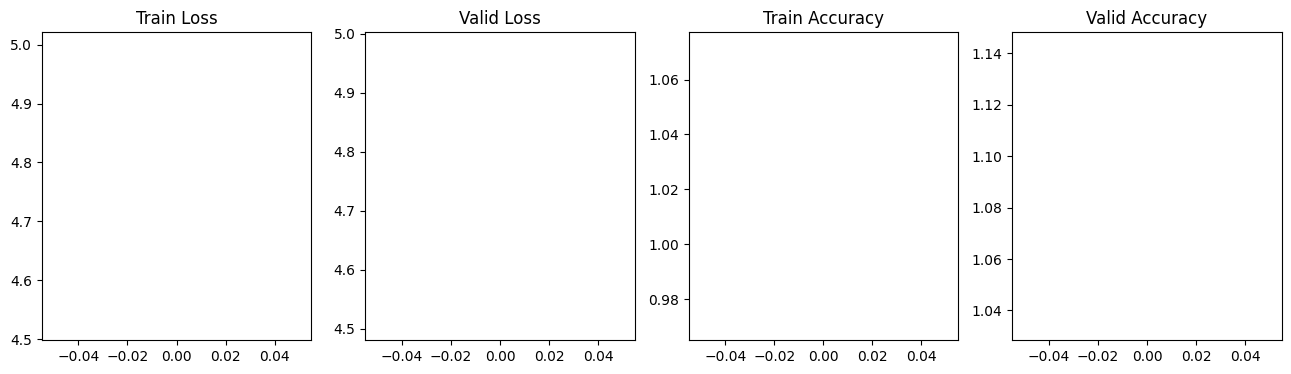

  4%|▍         | 2/51 [02:03<50:18, 61.60s/it]

SAVED-MODEL
Epoch: 2, Train Loss: 4.677658561967377, Train Accuracy: 1.1554480720139728, Valid Loss: 4.70161848801833, Valid Acc: 1.4510278113663846
SAVED-MODEL
Epoch: 3, Train Loss: 4.635280014103294, Train Accuracy: 1.1151417439204623, Valid Loss: 4.678306176112248, Valid Acc: 1.3301088270858525


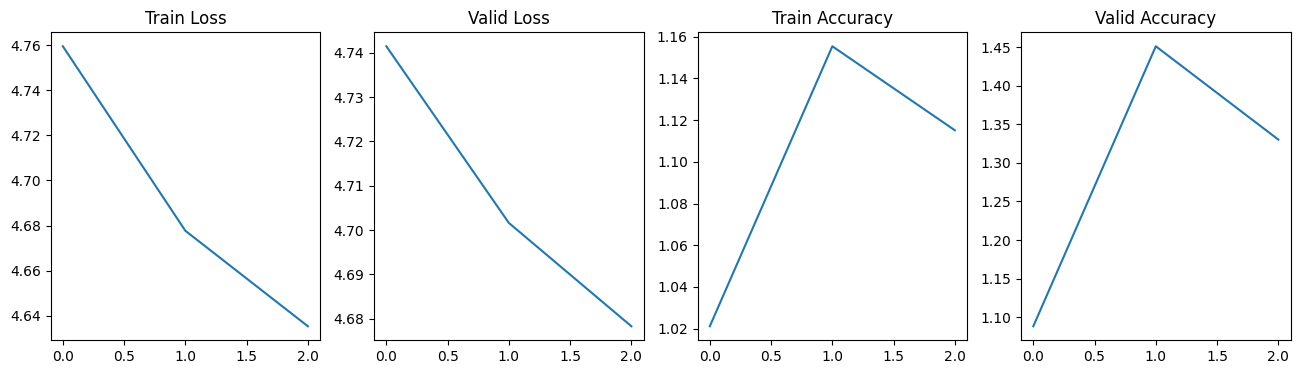

  8%|▊         | 4/51 [04:03<47:35, 60.76s/it]

SAVED-MODEL
Epoch: 4, Train Loss: 4.601721673949152, Train Accuracy: 1.3032379416901787, Valid Loss: 4.662581333747277, Valid Acc: 1.5719467956469166
SAVED-MODEL
Epoch: 5, Train Loss: 4.569256586906238, Train Accuracy: 1.7466075507187961, Valid Loss: 4.652638582082895, Valid Acc: 1.6928657799274487


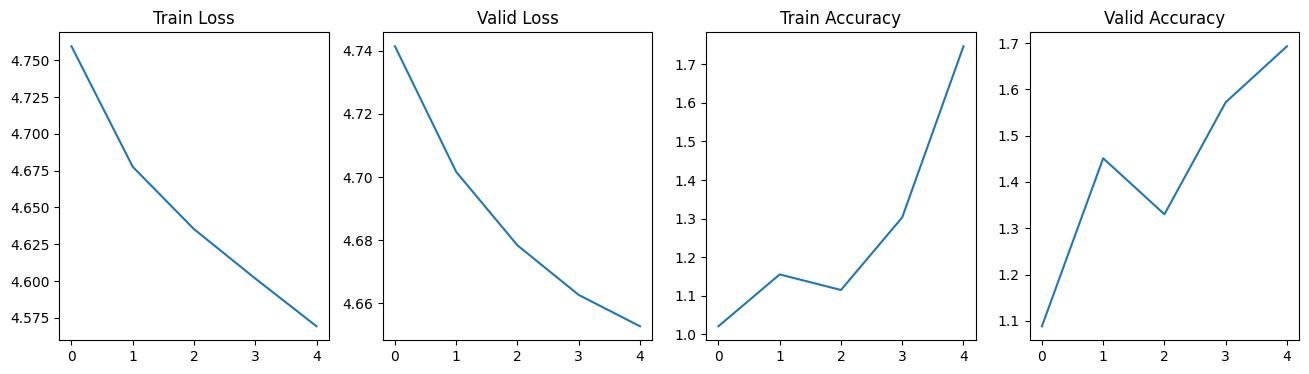

 12%|█▏        | 6/51 [06:03<45:10, 60.23s/it]

SAVED-MODEL
Epoch: 6, Train Loss: 4.553229772127592, Train Accuracy: 1.8406556496036544, Valid Loss: 4.64278741983267, Valid Acc: 1.6928657799274487
SAVED-MODEL
Epoch: 7, Train Loss: 4.521927552345471, Train Accuracy: 2.498992341797662, Valid Loss: 4.633761002467229, Valid Acc: 1.6928657799274487


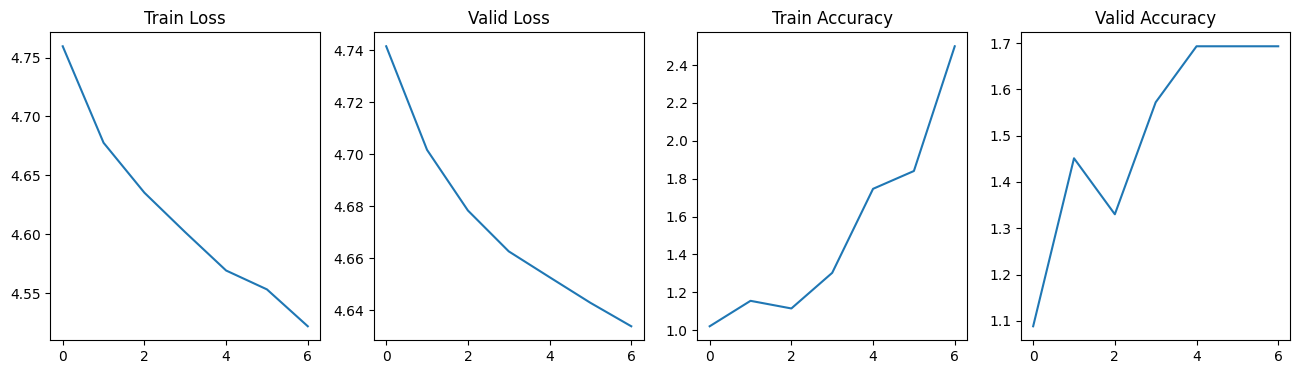

 16%|█▌        | 8/51 [08:03<43:06, 60.15s/it]

SAVED-MODEL
Epoch: 8, Train Loss: 4.498012086265107, Train Accuracy: 2.9826682789197903, Valid Loss: 4.62252950668335, Valid Acc: 1.8137847642079807
SAVED-MODEL
Epoch: 9, Train Loss: 4.474164151737833, Train Accuracy: 3.412602445250571, Valid Loss: 4.614376361553486, Valid Acc: 1.9347037484885128


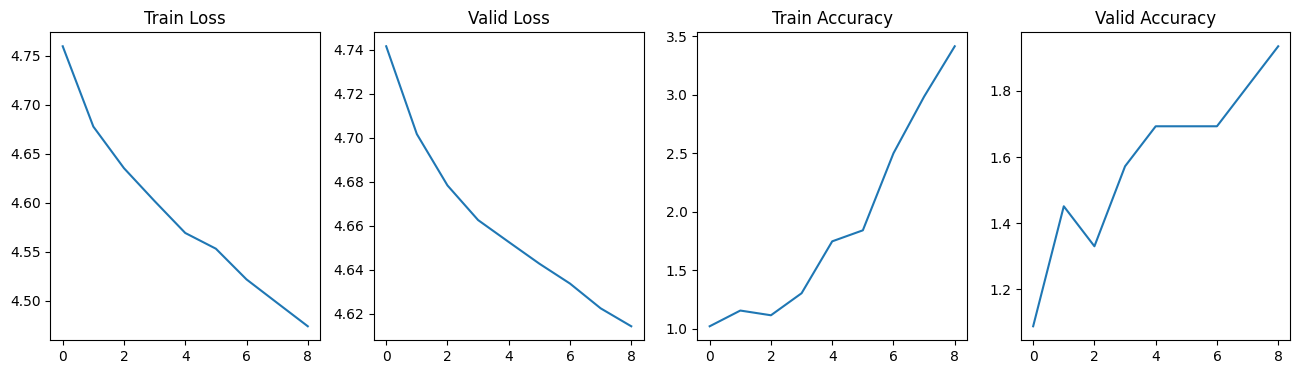

 20%|█▉        | 10/51 [10:05<41:23, 60.56s/it]

SAVED-MODEL
Epoch: 10, Train Loss: 4.450778586232764, Train Accuracy: 3.8559720542791887, Valid Loss: 4.6090491735018215, Valid Acc: 1.9347037484885128
SAVED-MODEL
Epoch: 11, Train Loss: 4.4273301760355634, Train Accuracy: 4.3933897621926645, Valid Loss: 4.5976386070251465, Valid Acc: 2.176541717049577


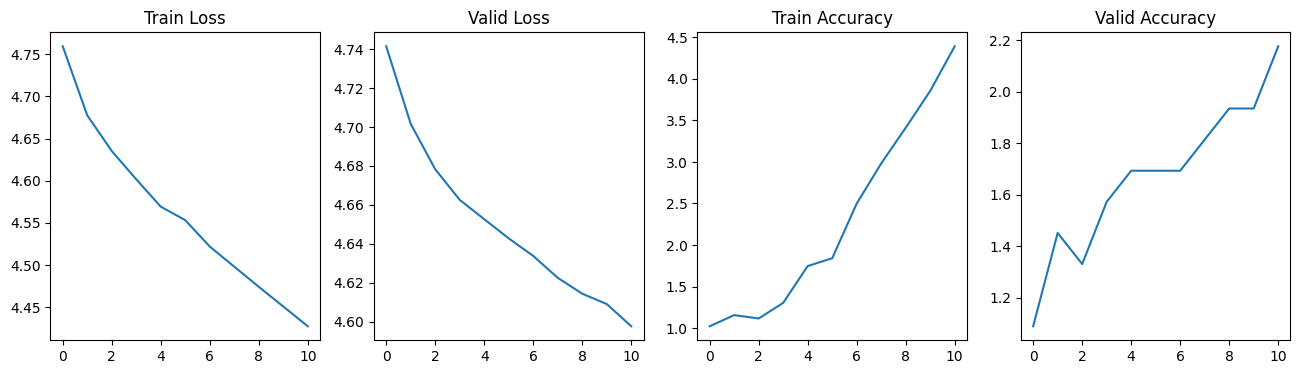

 24%|██▎       | 12/51 [12:07<39:32, 60.83s/it]

SAVED-MODEL
Epoch: 12, Train Loss: 4.406656175597101, Train Accuracy: 5.118903667875856, Valid Loss: 4.589851966271033, Valid Acc: 2.176541717049577
SAVED-MODEL
Epoch: 13, Train Loss: 4.383317886254726, Train Accuracy: 5.911594787048233, Valid Loss: 4.581855333768404, Valid Acc: 2.418379685610641


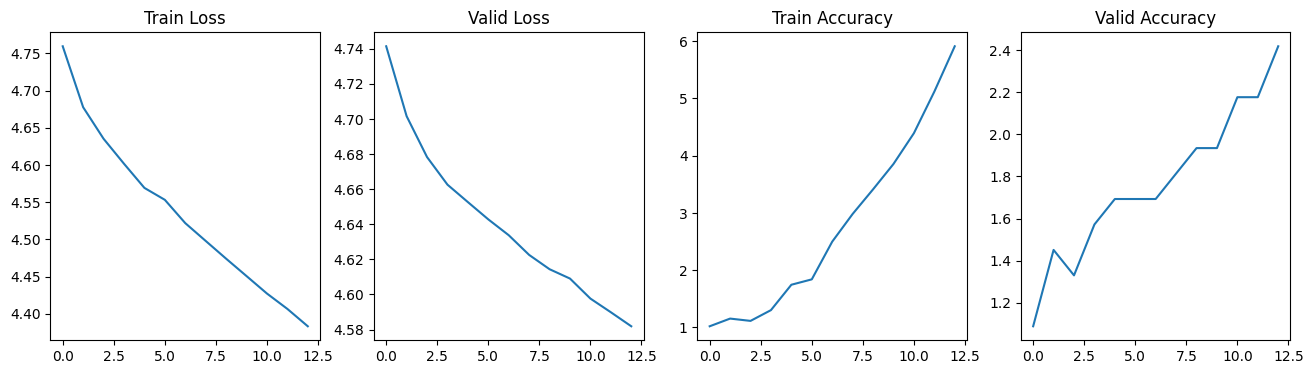

 27%|██▋       | 14/51 [13:59<35:55, 58.25s/it]

SAVED-MODEL
Epoch: 14, Train Loss: 4.360461100553855, Train Accuracy: 6.408706166868198, Valid Loss: 4.5741514059213495, Valid Acc: 2.418379685610641
SAVED-MODEL
Epoch: 15, Train Loss: 4.334010128282074, Train Accuracy: 6.9998656455730215, Valid Loss: 4.566216578850379, Valid Acc: 2.660217654171705


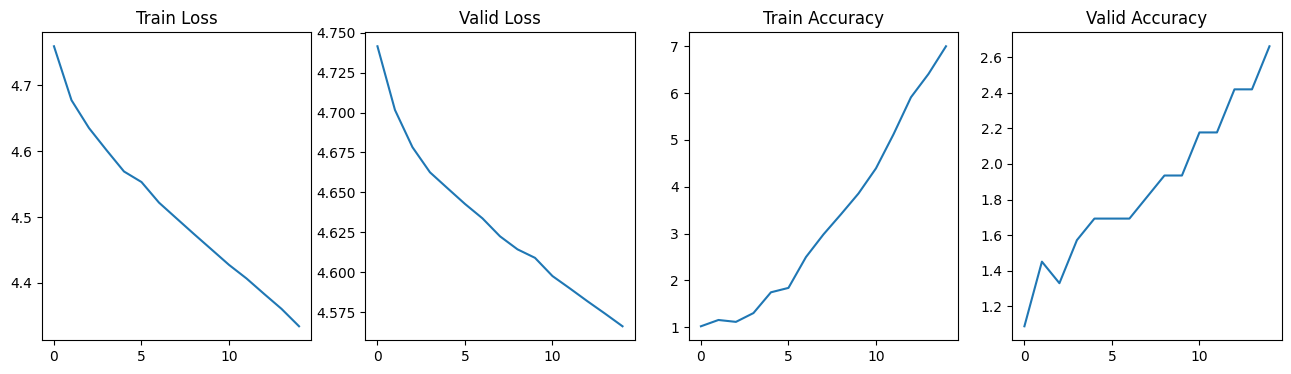

 31%|███▏      | 16/51 [15:50<33:09, 56.83s/it]

SAVED-MODEL
Epoch: 16, Train Loss: 4.3094048581571665, Train Accuracy: 8.034394733306462, Valid Loss: 4.557557949653039, Valid Acc: 2.2974607013301087
SAVED-MODEL
Epoch: 17, Train Loss: 4.288997927282611, Train Accuracy: 8.934569394061535, Valid Loss: 4.550726413726807, Valid Acc: 2.539298669891173


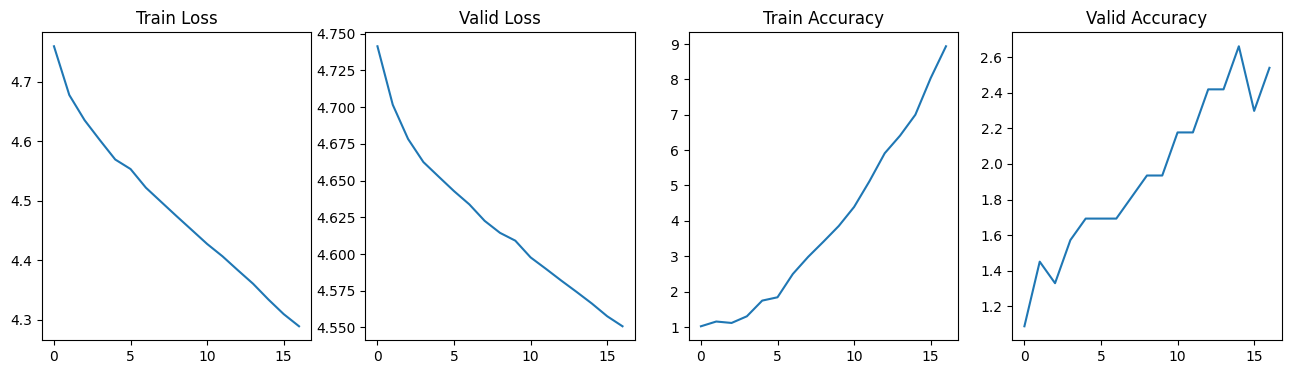

 35%|███▌      | 18/51 [17:42<31:02, 56.45s/it]

SAVED-MODEL
Epoch: 18, Train Loss: 4.267729355738713, Train Accuracy: 9.673518742442564, Valid Loss: 4.543933208172138, Valid Acc: 2.660217654171705
SAVED-MODEL
Epoch: 19, Train Loss: 4.24417928345183, Train Accuracy: 11.003627569528415, Valid Loss: 4.532847514519324, Valid Acc: 3.022974607013301


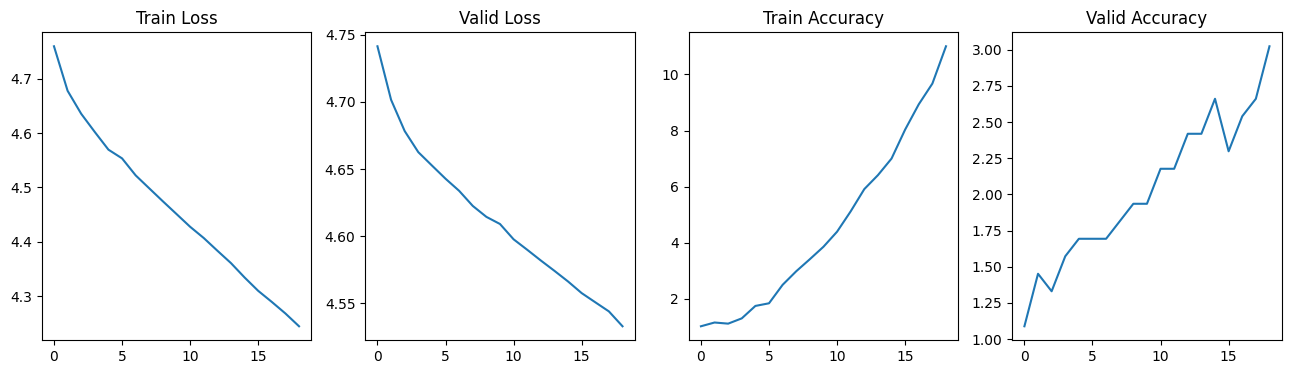

 39%|███▉      | 20/51 [19:37<29:27, 57.02s/it]

SAVED-MODEL
Epoch: 20, Train Loss: 4.223923583315988, Train Accuracy: 11.756012360607283, Valid Loss: 4.527282678163969, Valid Acc: 3.022974607013301
SAVED-MODEL
Epoch: 21, Train Loss: 4.197800126850096, Train Accuracy: 13.207040171973667, Valid Loss: 4.519976359147292, Valid Acc: 2.902055622732769


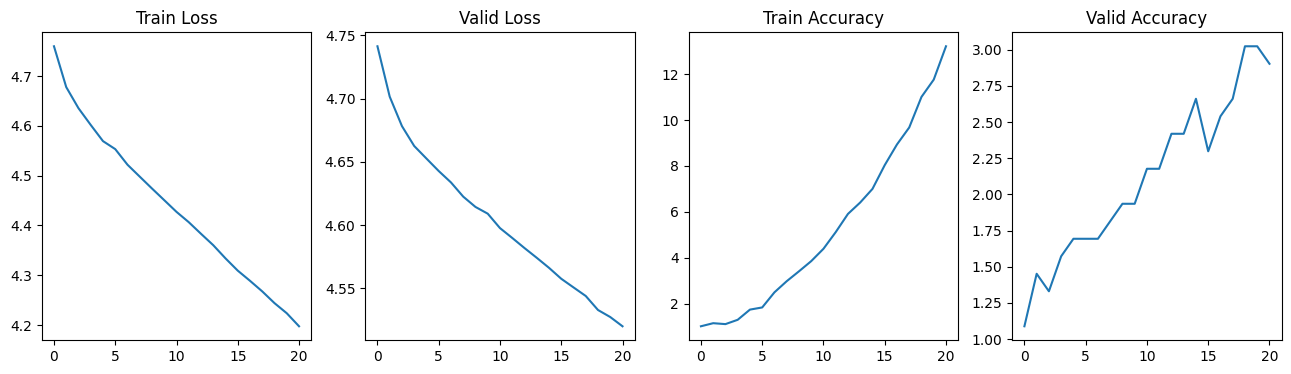

 43%|████▎     | 22/51 [21:36<28:00, 57.95s/it]

SAVED-MODEL
Epoch: 22, Train Loss: 4.174397704947708, Train Accuracy: 13.811635093376326, Valid Loss: 4.5118835522578316, Valid Acc: 2.781136638452237
SAVED-MODEL
Epoch: 23, Train Loss: 4.1522611328679275, Train Accuracy: 15.168614805857853, Valid Loss: 4.503192388094389, Valid Acc: 3.1438935912938333


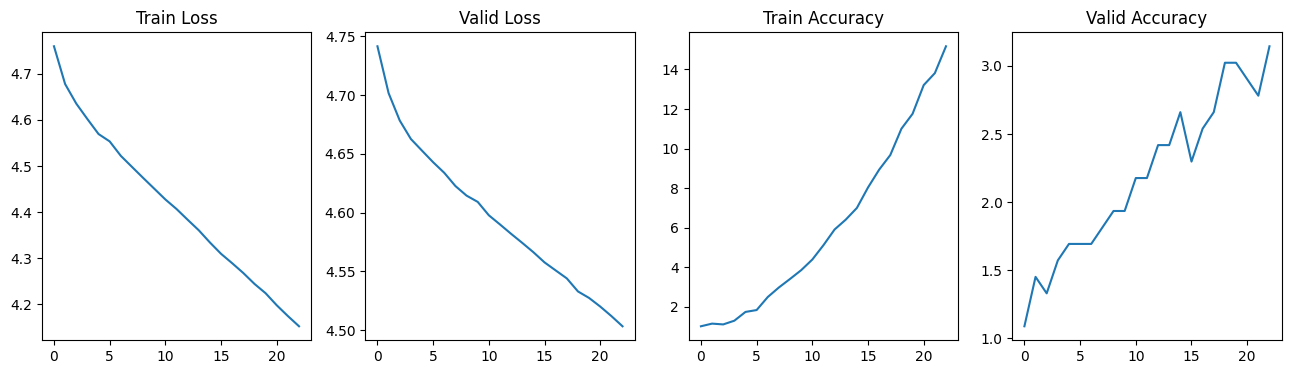

 47%|████▋     | 24/51 [23:30<25:52, 57.48s/it]

SAVED-MODEL
Epoch: 24, Train Loss: 4.13201222460494, Train Accuracy: 16.498723632943705, Valid Loss: 4.495774195744441, Valid Acc: 3.022974607013301
SAVED-MODEL
Epoch: 25, Train Loss: 4.104876387832511, Train Accuracy: 17.56012360607282, Valid Loss: 4.487166881561279, Valid Acc: 3.6275695284159615


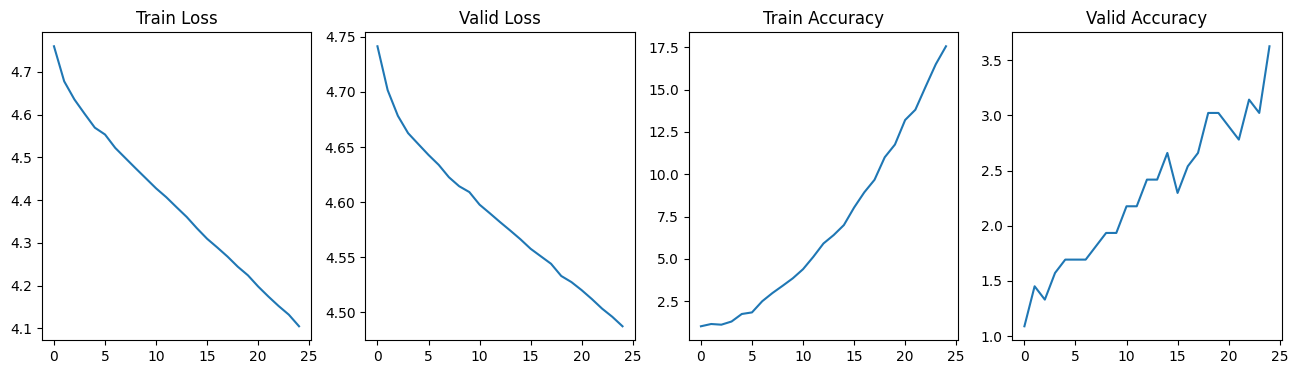

 51%|█████     | 26/51 [25:25<23:50, 57.20s/it]

SAVED-MODEL
Epoch: 26, Train Loss: 4.082732072243323, Train Accuracy: 18.68870079269112, Valid Loss: 4.479562099163349, Valid Acc: 3.506650544135429
SAVED-MODEL
Epoch: 27, Train Loss: 4.0618043883234005, Train Accuracy: 19.535133682654845, Valid Loss: 4.4668498406043415, Valid Acc: 3.8694074969770256


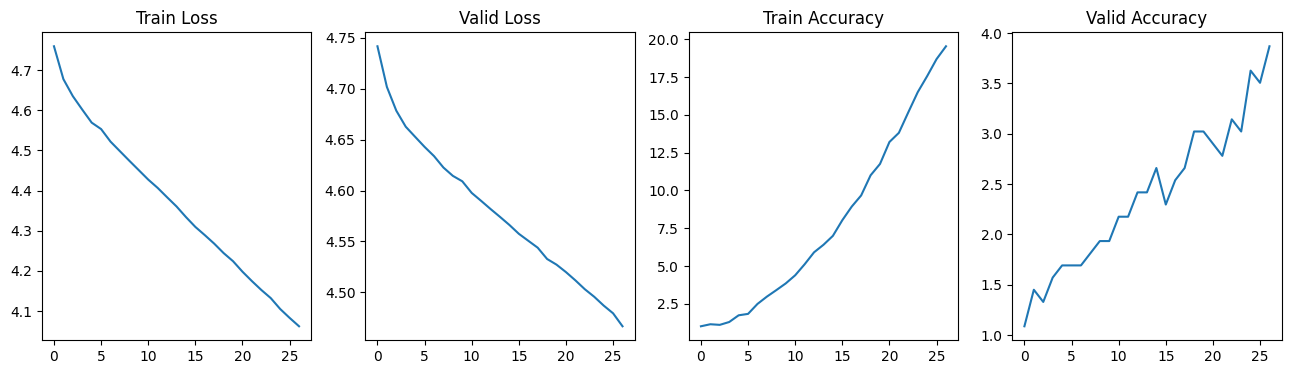

 55%|█████▍    | 28/51 [27:16<21:36, 56.38s/it]

SAVED-MODEL
Epoch: 28, Train Loss: 4.034060586212028, Train Accuracy: 20.81150073894935, Valid Loss: 4.4607211993290825, Valid Acc: 3.8694074969770256
SAVED-MODEL
Epoch: 29, Train Loss: 4.0059838152339315, Train Accuracy: 22.70589815934435, Valid Loss: 4.45310038786668, Valid Acc: 3.8694074969770256


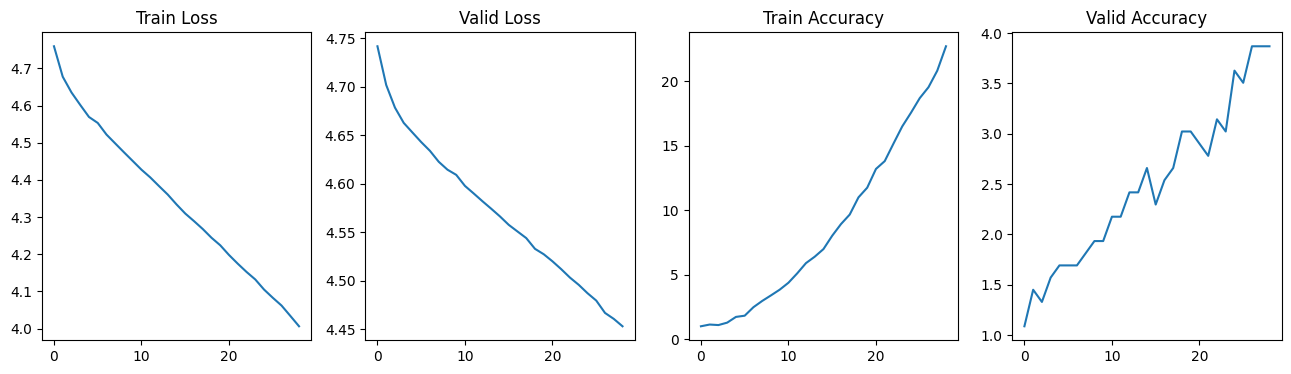

 59%|█████▉    | 30/51 [29:10<19:48, 56.60s/it]

SAVED-MODEL
Epoch: 30, Train Loss: 3.989082238613031, Train Accuracy: 23.22988042455999, Valid Loss: 4.4430730526263895, Valid Acc: 4.111245465538089
SAVED-MODEL
Epoch: 31, Train Loss: 3.960142453511556, Train Accuracy: 24.3987639392718, Valid Loss: 4.433937329512376, Valid Acc: 4.474002418379686


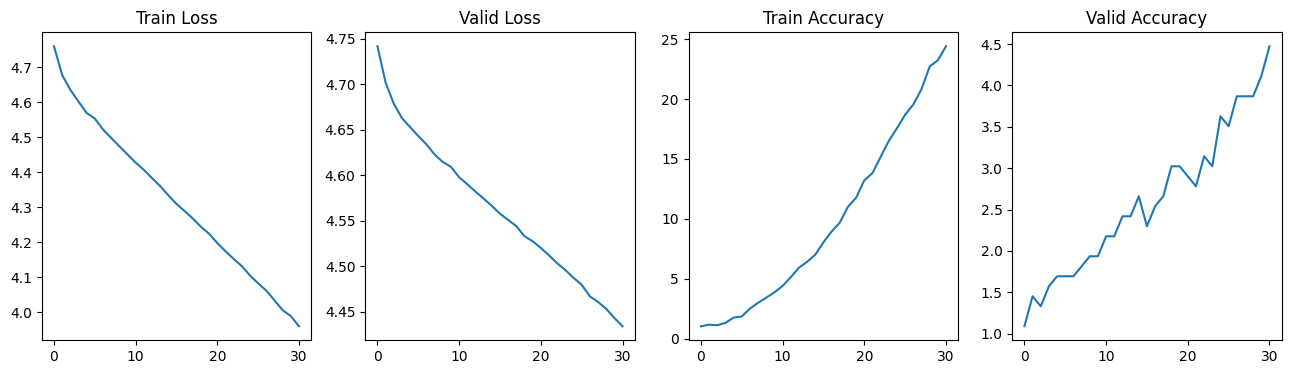

 63%|██████▎   | 32/51 [31:04<17:58, 56.74s/it]

SAVED-MODEL
Epoch: 32, Train Loss: 3.9373319312038584, Train Accuracy: 26.024452505710062, Valid Loss: 4.427076119642991, Valid Acc: 4.474002418379686
SAVED-MODEL
Epoch: 33, Train Loss: 3.909117769991231, Train Accuracy: 27.04554615074567, Valid Loss: 4.416036899273212, Valid Acc: 5.078597339782346


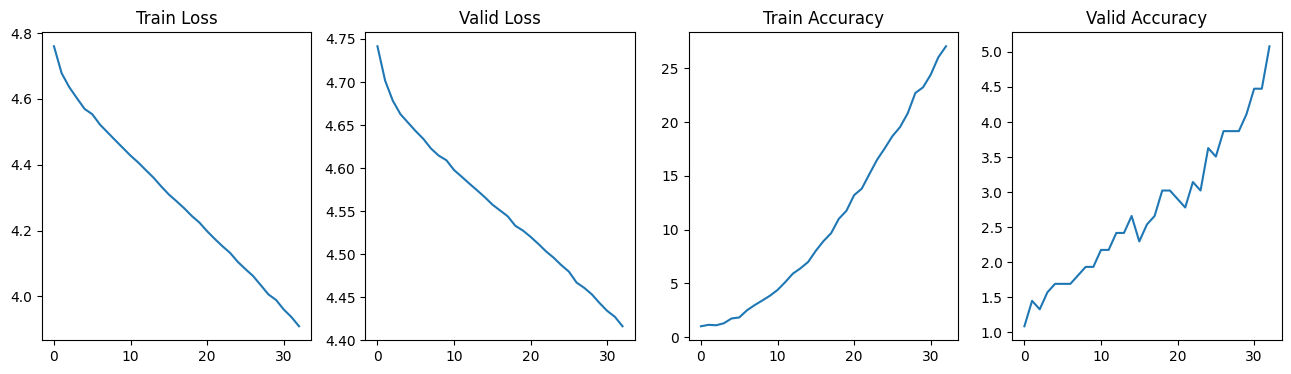

 67%|██████▋   | 34/51 [32:59<16:14, 57.31s/it]

SAVED-MODEL
Epoch: 34, Train Loss: 3.887587054162963, Train Accuracy: 27.85167271261588, Valid Loss: 4.407938186938946, Valid Acc: 4.71584038694075
SAVED-MODEL
Epoch: 35, Train Loss: 3.858247021324614, Train Accuracy: 29.27582963858659, Valid Loss: 4.3983947313748875, Valid Acc: 4.836759371221282


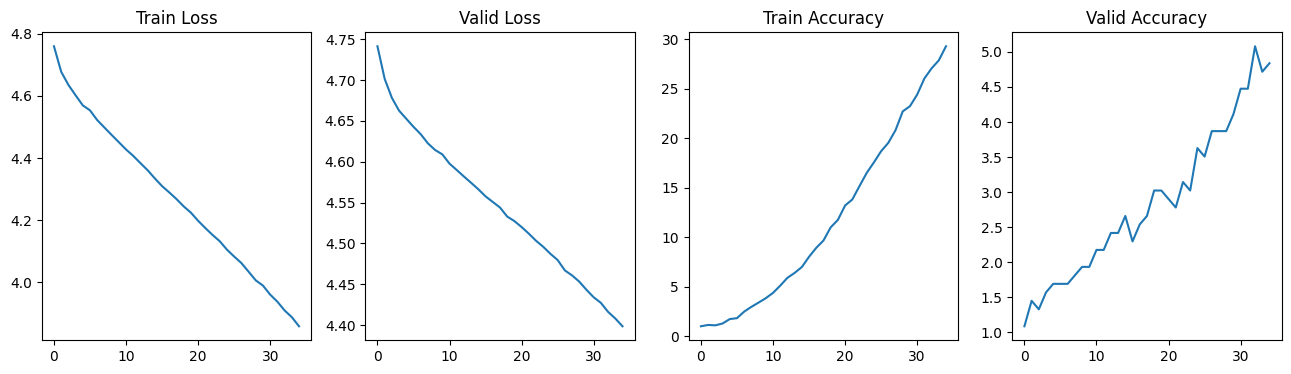

 71%|███████   | 36/51 [35:02<14:52, 59.52s/it]

SAVED-MODEL
Epoch: 36, Train Loss: 3.8308072701478615, Train Accuracy: 31.237404272470776, Valid Loss: 4.389508650853084, Valid Acc: 5.078597339782346
SAVED-MODEL
Epoch: 37, Train Loss: 3.8076767187852125, Train Accuracy: 32.12414349052801, Valid Loss: 4.378037122579721, Valid Acc: 5.4413542926239415


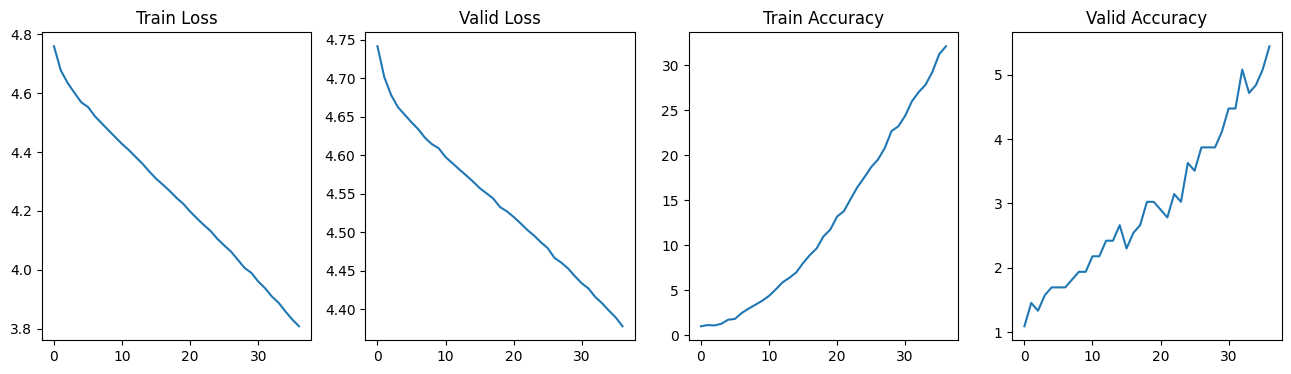

 75%|███████▍  | 38/51 [37:06<13:07, 60.60s/it]

SAVED-MODEL
Epoch: 38, Train Loss: 3.7861304466540995, Train Accuracy: 33.319897890635495, Valid Loss: 4.365819857670711, Valid Acc: 5.562273276904474
SAVED-MODEL
Epoch: 39, Train Loss: 3.756034777714656, Train Accuracy: 34.932151014375926, Valid Loss: 4.356106281280518, Valid Acc: 6.771463119709795


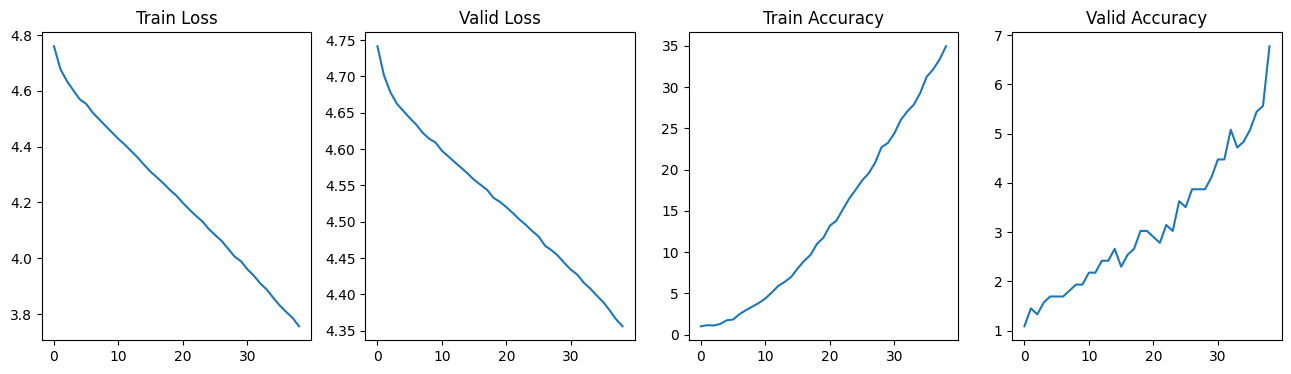

 76%|███████▋  | 39/51 [38:07<12:09, 60.83s/it]

In [11]:
torch.cuda.empty_cache()
device = torch.device('cuda:0')
# load pretrained dataset
# model = models.efficientnet_v2_s(pretrained=True)
# model.classifier[1].out_features = no_classes
model = models.resnet34(pretrained=True)
# changing the last layer to our cause
model.fc = nn.Linear(model.fc.in_features, no_classes)
model.to(device)
criterion = nn.CrossEntropyLoss()
learning_rate = 0.005
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
# optimizer = optim.Adam(params=model.parameters(), lr=learning_rate)
scheduler = lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.1)
# scheduler = lr_scheduler.ReduceLROnPlateau()
n_epochs = 51

result_folder = train_loop(n_epochs, model, optimizer, train_loader, val_loader, device, criterion, scheduler=None)